

--- Initializing Critically Damped Langevin ---


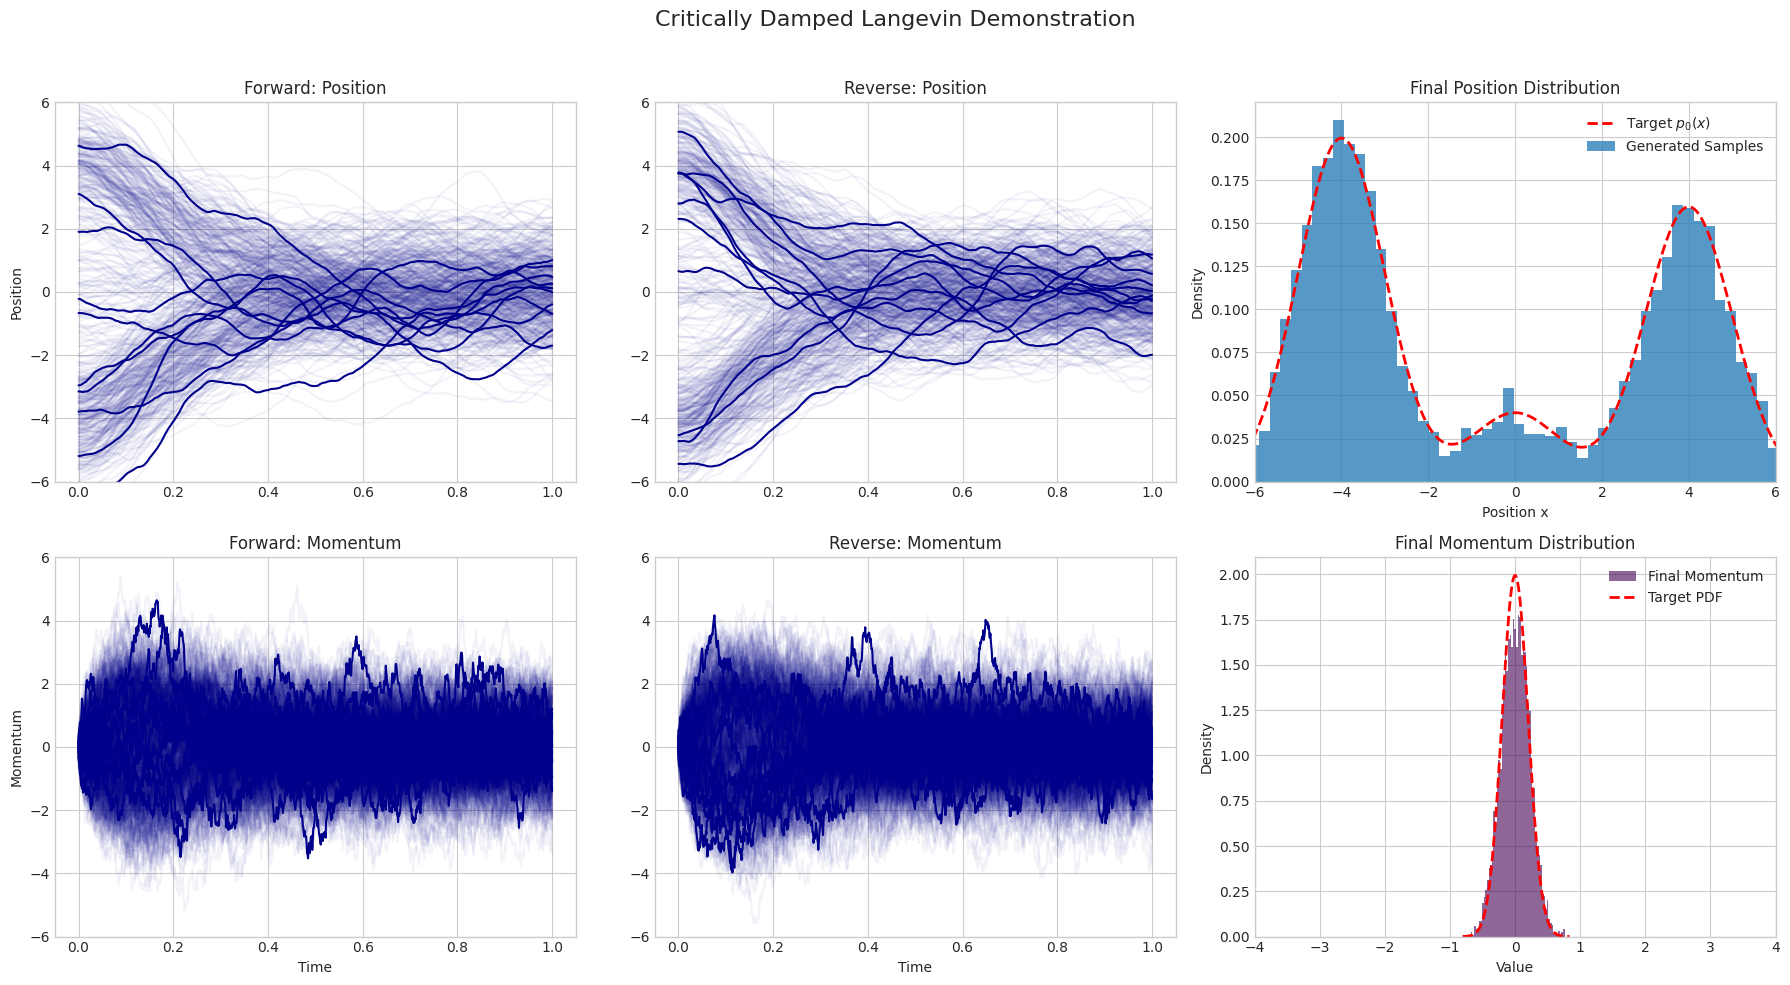



--- Initializing Generalized Langevin Diffusion ---


/disk/homeDIRS/rrajpal/GeneralizedLangevinDiffusion/gld/gmm/matrix_exp.py:9: RuntimeWarning: Input "a" has an eigenvalue pair whose sum is very close to or exactly zero. The solution is obtained via perturbing the coefficients.
  return solve_continuous_lyapunov(F, -Q)


ValueError: Expected value argument (Tensor of shape (5000, 3)) to be within the support (IndependentConstraint(Real(), 1)) of the distribution MultivariateNormal(loc: torch.Size([3]), covariance_matrix: torch.Size([3, 3])), but found invalid values:
tensor([[ 7.6559e-01,  4.6401e-01, -6.9729e-01],
        [ 2.9620e+35, -1.8237e+37, -5.6108e+37],
        [ 3.7386e+35, -2.3019e+37, -7.0818e+37],
        ...,
        [-1.7717e+00,  5.1062e-01,  7.1123e-02],
        [-1.8182e+00,  2.0332e-01, -7.2829e-01],
        [-4.3157e+20,  2.6572e+22,  8.1751e+22]])

In [ ]:
# TODO:

# Why aren't momentum and memory distributions lining up? Why is the SSCS reverse so skinny? Fix GLD numerical error outlier.
# Optimize GLD hyperparameters

# Implement PFODE/SDE with inbuilt solver
# Simulate forward exactly and with sscs.
# Implement training. Compare learnt score to true score. Maybe even regress against it with Fisher Matching. Compare DSM vs HSM vs True.
# Last step should correspond to denoising.

import torch
import matplotlib.pyplot as plt
import numpy as np
from diffusion.vpsde import VPSDE
from diffusion.cld import CriticallyDampedLangevin
from diffusion.gld import GeneralizedLangevinDiffusion

DEVICE = torch.device("cpu")

GMM_PARAMS = {
    'weights': [0.5, 0.1, 0.4],
    'means': [-4., 0., 4.],
    'stds': [1.,1., 1.]
}

n_plot, n_hist = 500, 5000

# vpsde_model = VPSDE(GMM_PARAMS)
# vpsde_model.run_demonstration(n_plot, n_hist)

print("\n" + "="*80 + "\n")

cld_model = CriticallyDampedLangevin(GMM_PARAMS)
cld_model.run_demonstration(n_plot, n_hist)

print("\n" + "="*80 + "\n")

gld_model = GeneralizedLangevinDiffusion(GMM_PARAMS)
gld_model.run_demonstration(n_plot, n_hist)